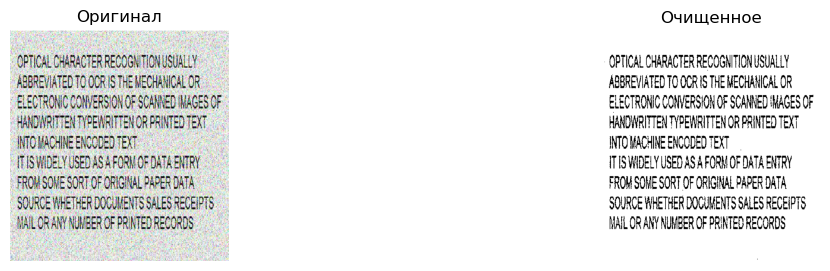

In [10]:
import cv2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Загрузка изображения
img = cv2.imread("1234.png")

# Увеличим изображение для лучшего OCR
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# Перевод в grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Удаление цветного шума
denoise = cv2.fastNlMeansDenoising(gray, h=15)

# Бинаризация
thresh = cv2.threshold(
    denoise, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)[1]

# Немного утолщаем текст
kernel = np.ones((1,1), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)


# Сохранение результата
cv2.imwrite("clean.png", clean)

plt.figure(figsize=(14, 3))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(clean, cmap='gray')
plt.axis('off')
plt.title('Очищенное')



plt.show()